In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [4]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [5]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [6]:
from numba import njit
import numpy as np
import xarray as xr
from numba import njit

@njit(cache=True, fastmath=True)
def _mask_1d(values, k_eff, mean, std, safe_lo, safe_hi,
             hard_clip_eff, p95, p95_margin_eff,
             q1, q3, use_quantiles, iqr_mult):
    n = values.shape[0]
    dev = np.zeros(n, dtype=np.bool_)
    last_kept = np.nan; have_last=False; prev_was_kept=False
    z_enabled = np.isfinite(std) and std > 0.0
    p95_gate = p95 + p95_margin_eff if np.isfinite(p95) else np.inf
    iqr = q3 - q1
    lo_iqr = q1 - iqr_mult * iqr
    hi_iqr = q3 + iqr_mult * iqr
    for i in range(n):
        x = values[i]
        if not np.isfinite(x): dev[i]=True; prev_was_kept=False; continue
        if np.abs(x) > hard_clip_eff: dev[i]=True; prev_was_kept=False; continue
        if (x >= safe_lo) and (x <= safe_hi): dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True; continue
        if use_quantiles and ((x < lo_iqr) or (x > hi_iqr)): dev[i]=True; prev_was_kept=False; continue
        if z_enabled:
            z = (x - mean) / std
            if np.abs(z) > k_eff: dev[i]=True; prev_was_kept=False; continue
        if not prev_was_kept:
            if x <= p95_gate: dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
            else: dev[i]=True; prev_was_kept=False
            continue
        if have_last:
            allowed = 1.5 if (-1.0 <= last_kept <= 1.0) else 0.5
            if np.abs(x - last_kept) > allowed: dev[i]=True; prev_was_kept=False; continue
        dev[i]=False; last_kept=x; have_last=True; prev_was_kept=True
    return dev

# FAST block-drift mask: EW-quantile (median) + run-length
@njit(cache=True, fastmath=True)
def _block_mask_1d(values, med_thresh, min_run, alpha):
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    m = 0.0                        # EW median estimate (starts near 0 for residuals)
    run = 0                        # consecutive samples with |m| > threshold
    for i in range(n):
        x = values[i]
        if np.isfinite(x):
            # Robbins–Monro quantile update (tau=0.5 -> median)
            m += alpha * (0.5 - (1.0 if x < m else 0.0))
            if np.abs(m) > med_thresh:
                run += 1
                if run == min_run:
                    # backfill the initial block once threshold run is reached
                    start = i - min_run + 1
                    for j in range(start, i + 1):
                        block[j] = True
                elif run > min_run:
                    block[i] = True
            else:
                run = 0
        else:
            run = 0  # NaN breaks the block
    return block
@njit(cache=True, fastmath=True)
def _yrmean_block_mask_1d(values, yr_mean_vals, good_year_vals,
                          mean_abs_thresh, band, min_run):
    """
    Flag contiguous runs that stay near the (shifted) yearly mean, but only
    in years where |yearly mean| > mean_abs_thresh and coverage was 'good'.
    """
    n = values.shape[0]
    block = np.zeros(n, dtype=np.bool_)
    run = 0
    start = 0
    for i in range(n):
        x = values[i]
        if not np.isfinite(x):
            run = 0
            continue

        if not good_year_vals[i]:
            # year not eligible: reset run
            run = 0
            continue

        ymean = yr_mean_vals[i]
        if not np.isfinite(ymean) or (np.abs(ymean) <= mean_abs_thresh):
            # yearly mean not "shifted" enough
            run = 0
            continue

        # Are we "near" the shifted yearly mean?
        if np.abs(x - ymean) <= band:
            if run == 0:
                start = i
            run += 1
            if run == min_run:
                for j in range(start, i + 1):
                    block[j] = True
            elif run > min_run:
                block[i] = True
        else:
            run = 0
    return block
def filter_residual(
    ds: xr.Dataset,
    var: str = "residual",
    dim: str | None = None,
    base_k: float = 5.0,
    safe_keep_band: tuple[float, float] = (-2.0, 2.0),
    hard_clip: float = 3.0,
    p95_margin: float = 0.5,
    station_dim: str = "station",
    min_frac_year: float = 0.5,
    kurt_hard: float = 1.0,
    # mean-shift block knobs
    year_mean_abs_thresh: float = 1.0,   # consider a year "shifted" if |year mean| > 1 m
    block_band: float = 0.5,             # samples within ±band of the yearly mean count toward a block
    min_run: int = 60,                   # consecutive samples near the mean to declare a block
):
    da = ds[var]; dim = da.dims[0] if dim is None else dim
    ds = ds.sortby(dim); da = ds[var].astype("float64")

    # --- robust stats (unchanged)
    mu   = da.mean(dim=dim, skipna=True)
    sig  = da.std(dim=dim,  skipna=True)
    p95  = da.quantile(0.95, dim=dim, skipna=True)
    qs   = da.quantile([0.25, 0.75], dim=dim, skipna=True)
    q1, q3 = qs.sel(quantile=0.25), qs.sel(quantile=0.75)

    m2 = da.var(dim=dim, skipna=True)
    m4 = ((da - mu) ** 4).mean(dim=dim, skipna=True)
    ex_kurt = xr.where(m2 > 0, m4 / (m2 ** 2) - 3.0, 0.0)
    heavy = ex_kurt > kurt_hard

    k_eff          = xr.where(heavy, base_k / 2.5, base_k)
    iqr_mult       = xr.where(heavy, 1.0, 1.5)
    hard_clip_eff  = xr.where(heavy, 2.0, hard_clip)
    p95_margin_eff = xr.where(heavy, 0.1, p95_margin)
    use_quantiles  = heavy

    dev_point = xr.apply_ufunc(
        _mask_1d,
        da, k_eff, mu, sig,
        xr.DataArray(safe_keep_band[0]), xr.DataArray(safe_keep_band[1]),
        hard_clip_eff, p95, p95_margin_eff,
        q1, q3, use_quantiles, iqr_mult,
        input_core_dims=[[dim], [], [], [], [], [], [], [], [], [], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    # --- yearly mean and coverage (unchanged)
    present = da.notnull()
    cov_year = present.groupby(f"{dim}.year").mean(dim=dim)         # fraction present per year
    yr_mean  = da.groupby(f"{dim}.year").mean(dim=dim, skipna=True)  # mean per year
    good_year = cov_year > min_frac_year

    # --- NEW: broadcast per-year values back to each timestamp by selecting with a per-sample 'year' indexer
    # Ensure time axis is datetime64
    if not np.issubdtype(ds[dim].dtype, np.datetime64):
        # If your coord isn't datetime64, convert it here (one-time)
        ds = ds.assign_coords({dim: xr.converters.to_datetime64(ds[dim])})
        da = ds[var].astype("float64")

    year_indexer = xr.DataArray(
        ds[dim].dt.year,         # vector of years for every sample along `dim`
        dims=dim,
        coords={dim: ds[dim]}
    )

    # These now have the SAME dims as `da` (broadcasted back from 'year')
    yr_mean_full   = yr_mean.sel(year=year_indexer)
    good_year_full = good_year.sel(year=year_indexer)

    # --- block detector: runs near the shifted yearly mean
    dev_block = xr.apply_ufunc(
        _yrmean_block_mask_1d,
        da,
        yr_mean_full,
        good_year_full,
        xr.DataArray(year_mean_abs_thresh),
        xr.DataArray(block_band),
        xr.DataArray(np.int64(min_run)),
        input_core_dims=[[dim], [dim], [dim], [], [], []],
        output_core_dims=[[dim]],
        vectorize=True, dask="parallelized",
        output_dtypes=[bool],
    )

    deviant = dev_point | dev_block

    out = ds.copy()
    out[f"{var}_is_deviant"] = deviant
    out[var] = da.where(~deviant)

    if station_dim in out.dims:
        extra = [d for d in cov_year.dims if d not in (station_dim, "year")]
        cov_check = cov_year if not extra else cov_year.mean(dim=extra)
        keep_station = (cov_check > min_frac_year).any(dim="year")
        out = out.isel({station_dim: keep_station})

    return out, out[f"{var}_is_deviant"]
# ds: xr.Dataset with a variable named "residual" along dimension "time"
ds_filtered, dev_mask = filter_residual(ds_recent, var="residual", dim="valid_time")
ds = ds_filtered

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [14]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Reuse coords & units from your code
proj = ccrs.PlateCarree()
valid_pts = np.isfinite(lons) & np.isfinite(lats)

def quick_map(values, title, cbarlabel="", cmap="plasma_r", vmin=None, vmax=None):
    vals = np.asarray(values)
    fig = plt.figure(figsize=(10,8))
    ax = plt.axes(projection=proj)

    # Extent padding
    xmin, xmax = float(np.nanmin(lons[valid_pts])), float(np.nanmax(lons[valid_pts]))
    ymin, ymax = float(np.nanmin(lats[valid_pts])), float(np.nanmax(lats[valid_pts]))
    pad_x = max(0.5, 0.05 * (xmax - xmin))
    pad_y = max(0.5, 0.05 * (ymax - ymin))
    ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)

    # Base map
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.right_labels = False; gl.top_labels = False

    sc = ax.scatter(lons, lats, c=vals, s=150, cmap=cmap, vmin=vmin, vmax=vmax,
                    edgecolor="black", linewidth=0.4, alpha=0.95, transform=proj)
    cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
    cb.set_label(cbarlabel)
    ax.set_title(title)
    plt.tight_layout(); plt.show()


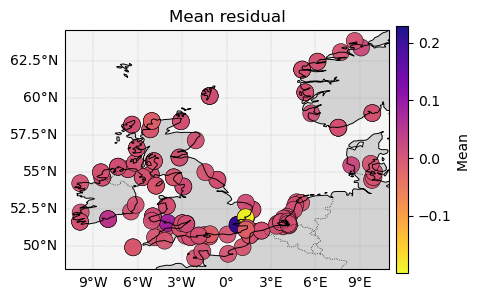

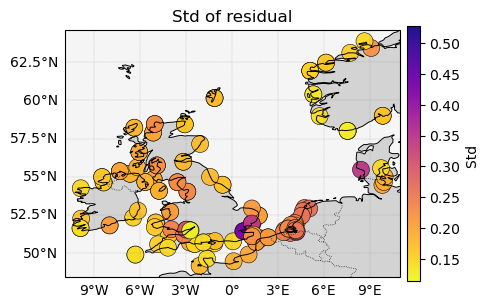

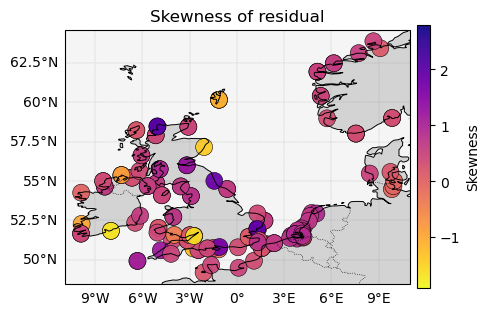

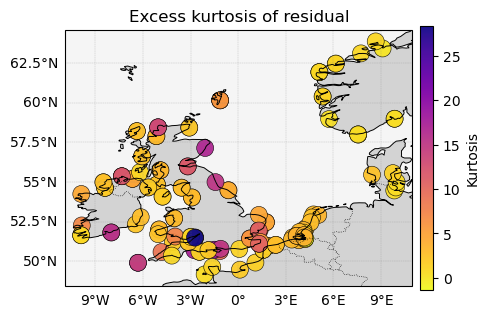

In [13]:
from scipy.stats import skew, kurtosis

# Mean & std over time
mean_res = ds["residual"].mean("valid_time", skipna=True)            # (station,)
std_res  = ds["residual"].std("valid_time", skipna=True)

# Skew & kurtosis per station (operate on numpy with nan-handling)
def per_station(func):
    out = np.full(ds.sizes["station"], np.nan)
    for i in range(ds.sizes["station"]):
        x = ds["residual"].isel(station=i).values
        x = x[np.isfinite(x)]
        if x.size > 5:
            out[i] = func(x)
    return out

skew_res = per_station(lambda x: skew(x, bias=False))
kurt_res = per_station(lambda x: kurtosis(x, fisher=True, bias=False))

quick_map(mean_res.values, "Mean residual", f"Mean {f'({units})' if units else ''}")
quick_map(std_res.values,  "Std of residual", f"Std {f'({units})' if units else ''}")
quick_map(skew_res,        "Skewness of residual", "Skewness")
quick_map(kurt_res,        "Excess kurtosis of residual", "Kurtosis")


In [16]:
for T in [2, 5, 10, 20, 50]:
    rl = annual_max.quantile(1 - 1/T, dim="year", skipna=True)

Ts = [2, 5, 10, 20, 50]
rls = {T: annual_max.quantile(1 - 1/T, dim="year", skipna=True) for T in Ts}

for T in [2,10,50]:
    quick_map(rls[T].values.where(n_years>=3), f"{T}-year return level",
              f"RL{T} {f'({units})' if units else ''}")

# Curves for a few representative stations (best data coverage)
top_idx = np.argsort(-n_years.values)[:6]  # 6 stations with most years
plt.figure(figsize=(6,4))
for i in top_idx:
    ys = [rls[T].values[i] for T in Ts]
    plt.plot(Ts, ys, marker="o", label=f"stn {int(i)}")
plt.xscale("log"); plt.xlabel("Return period (years)")
plt.ylabel(f"Return level {f'({units})' if units else ''}")
plt.title("Return level spectrum for selected stations")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'where'

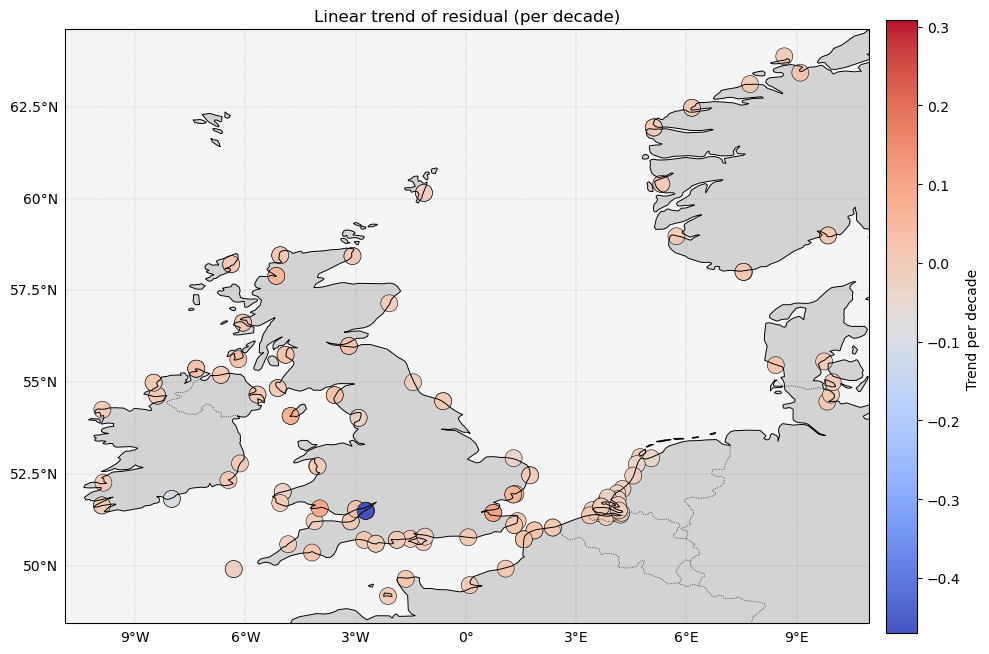

In [ ]:
# Convert time -> decimal years
t = pd.to_datetime(ds["valid_time"].values)
t_year = t.year + (t.dayofyear - 1)/365.25

slope_decade = np.full(ds.sizes["station"], np.nan)
for i in range(ds.sizes["station"]):
    y = ds["residual"].isel(station=i).values
    mask = np.isfinite(y)
    if mask.sum() > 24:  # need enough points
        p = np.polyfit(t_year[mask], y[mask], 1)  # p[0]=slope per year
        slope_decade[i] = p[0] * 10.0

quick_map(slope_decade, "Linear trend of residual (per decade)",
          f"Trend per decade {f'({units})' if units else ''}", cmap="coolwarm")

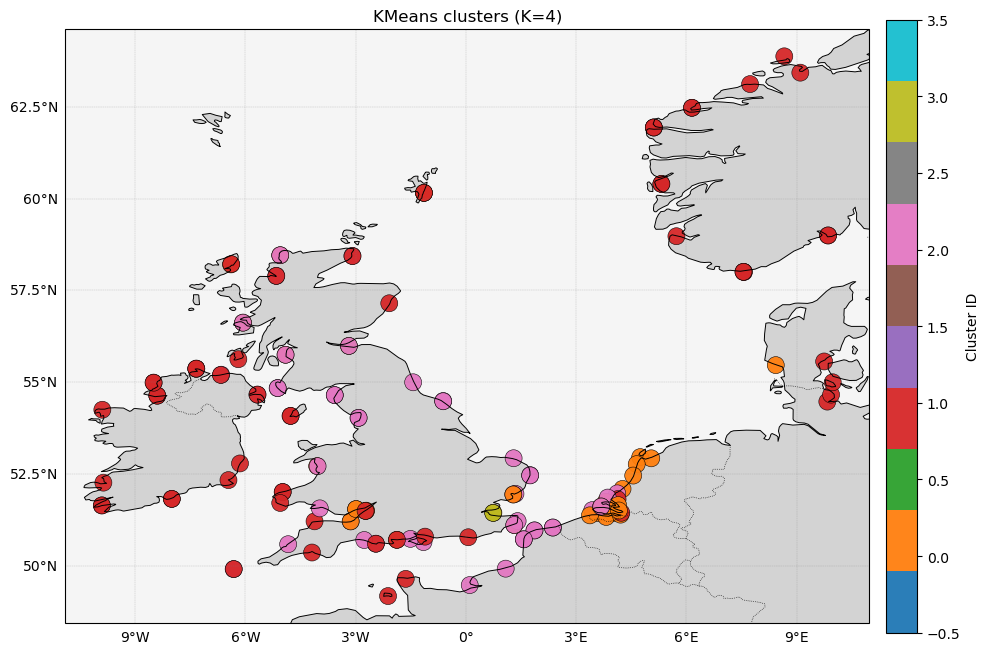

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = np.column_stack([
    mean_res.values, std_res.values, tenyr_rl.values
])
mask = np.all(np.isfinite(features), axis=1)
K = 4
labels = np.full(ds.sizes["station"], np.nan)
scaler = StandardScaler()
Xk = scaler.fit_transform(features[mask])
labels_k = KMeans(n_clusters=K, n_init="auto", random_state=0).fit_predict(Xk)
labels[mask] = labels_k

quick_map(labels, f"KMeans clusters (K={K})", "Cluster ID", cmap="tab10",
          vmin=-0.5, vmax=K-0.5)


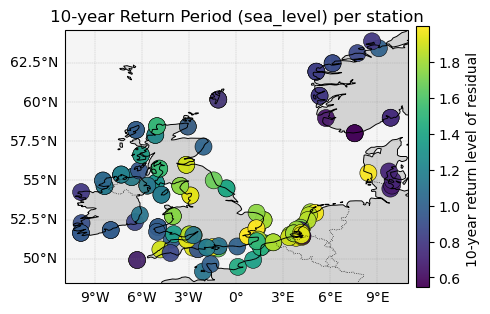

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Annual maxima of sea_level per station
annual_max = ds["residual"].groupby("valid_time.year").max("valid_time", skipna=True)  # (station, year)

# 2) Require at least 10 annual maxima to estimate a 10-yr RL
n_years = annual_max.notnull().sum("year")                                              # (station,)
tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                             # (station,)
tenyr_rl = tenyr_rl.where(n_years >= 3)                                                # mask weak stations

# 3) Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Optional: units for colorbar label if present
units = ds["sea_level"].attrs.get("units", "")

# 4) Quick Cartopy plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with padding from station points
valid = np.isfinite(lons) & np.isfinite(lats)
xmin, xmax = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
ymin, ymax = float(np.nanmin(lats[valid])), float(np.nanmax(lats[valid]))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
#ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 5) Plot stations (color = 10-yr return level)
sc = ax.scatter(
    lons, lats,
    c=vals, s=150, cmap="viridis",
    edgecolor="black", linewidth=0.4, alpha=0.95,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(f"10-year return level of residual {f'({units})' if units else ''}")

ax.set_title("10-year Return Period (sea_level) per station")
plt.tight_layout()
plt.show()


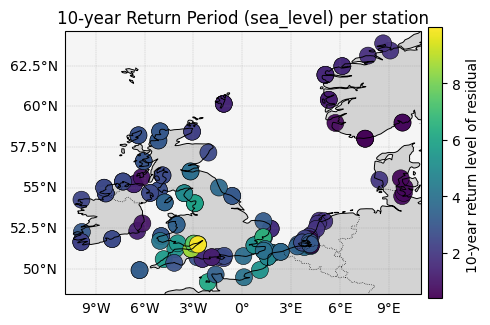

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1) Annual maxima of sea_level per station
annual_max = ds["sea_level"].groupby("valid_time.year").max("valid_time", skipna=True)  # (station, year)

# 2) Require at least 10 annual maxima to estimate a 10-yr RL
n_years = annual_max.notnull().sum("year")                                              # (station,)
tenyr_rl = annual_max.quantile(0.9, dim="year", skipna=True)                             # (station,)
tenyr_rl = tenyr_rl.where(n_years >= 3)                                                # mask weak stations

# 3) Pull station coords (1D over 'station')
lons = ds["station_longitude"].values
lats = ds["station_latitude"].values
vals = tenyr_rl.values

# Optional: units for colorbar label if present
units = ds["sea_level"].attrs.get("units", "")

# 4) Quick Cartopy plot
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(5, 4))
ax = plt.axes(projection=proj)

# Extent with padding from station points
valid = np.isfinite(lons) & np.isfinite(lats)
xmin, xmax = float(np.nanmin(lons[valid])), float(np.nanmax(lons[valid]))
ymin, ymax = float(np.nanmin(lats[valid])), float(np.nanmax(lats[valid]))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)
#ax.set_extent([4.5, 10, 60, 65], crs=proj)

# Base features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="whitesmoke")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False
gl.top_labels = False

# 5) Plot stations (color = 10-yr return level)
sc = ax.scatter(
    lons, lats,
    c=vals, s=150, cmap="viridis",
    edgecolor="black", linewidth=0.4, alpha=0.95,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label(f"10-year return level of residual {f'({units})' if units else ''}")

ax.set_title("10-year Return Period (sea_level) per station")
plt.tight_layout()
plt.show()


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_99692/3822203036.py:10: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  n_total = ds.dims.get("station", ds["sea_level"].sizes.get("station"))


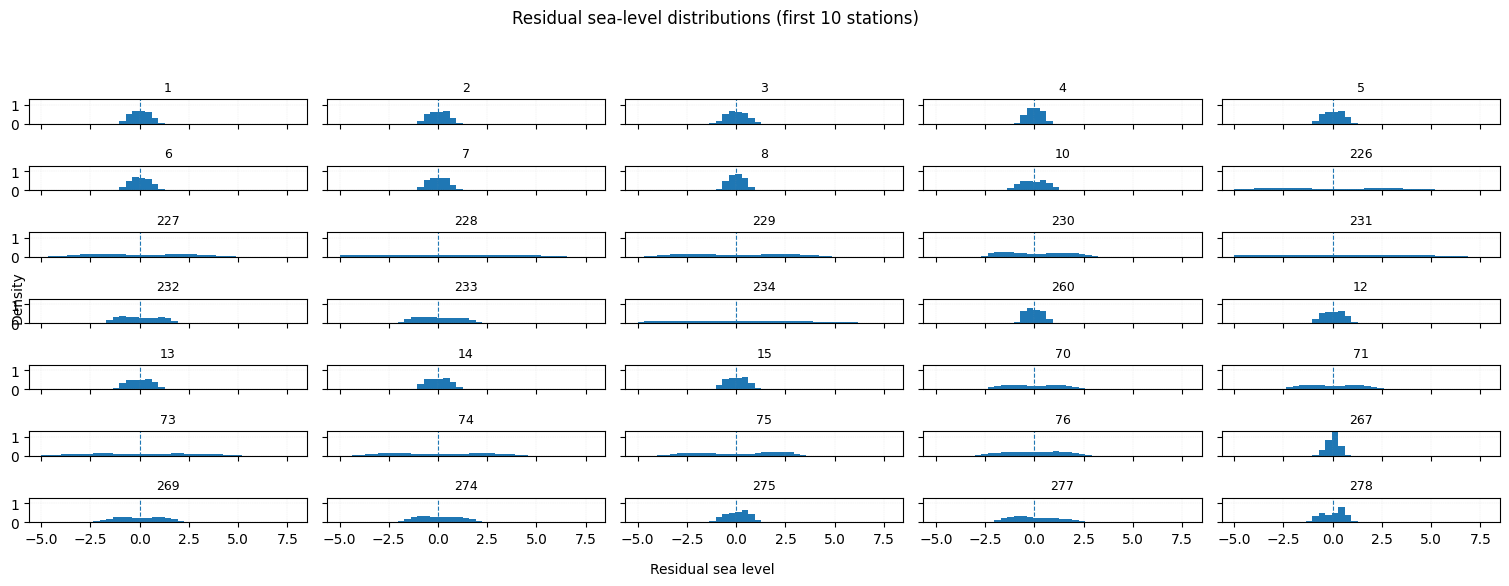

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Config ---
max_stations = 35
ncols = 5

# Slice the first N stations
n_total = ds.dims.get("station", ds["sea_level"].sizes.get("station"))
n = min(max_stations, n_total)
data = ds["sea_level"].isel(station=slice(0, n))  # (station, valid_time)

# Pull labels if available
def station_labels_from_ds(ds, n):
    candidates = ["station_name", "name", "station_id", "id", "station"]
    for key in candidates:
        if key in ds:
            try:
                return [str(v) for v in ds[key].isel(station=slice(0, n)).values]
            except Exception:
                pass
        if key in ds.coords:
            try:
                return [str(v) for v in ds.coords[key].isel(station=slice(0, n)).values]
            except Exception:
                pass
    return [f"Station {i}" for i in range(n)]

labels = station_labels_from_ds(ds, n)

# Units for axis label if present
units = ds["sea_level"].attrs.get("units", "")

# Compute common bins across all selected stations (ignoring NaNs)
vals_all = data.values  # shape: (station, time)
finite = np.isfinite(vals_all)
if not np.any(finite):
    raise ValueError("All values are NaN for the selected stations.")
vmin = float(np.nanmin(vals_all))
vmax = float(np.nanmax(vals_all))
# Guard against zero-width range
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = vmin - 0.5, vmax + 0.5
bins = np.linspace(vmin, vmax, 40)

# Figure layout
nrows = math.ceil(n / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6), sharex=True, sharey=True)
if isinstance(axes, np.ndarray):
    axes = axes.ravel()
else:
    axes = [axes]

# Plot each station histogram
for i in range(n):
    ax = axes[i]
    arr = vals_all[i, :]
    arr = arr[np.isfinite(arr)]
    ax.hist(arr, bins=bins, density=True)
    ax.axvline(0.0, linestyle="--", linewidth=0.8)
    ax.set_title(labels[i], fontsize=9)
    ax.grid(alpha=0.3, linestyle="--", linewidth=0.3)

# Hide any unused subplots
for j in range(n, nrows * ncols):
    axes[j].axis("off")

# Labels and layout
fig.suptitle("Residual sea-level distributions (first 10 stations)", fontsize=12)
fig.text(0.5, 0.04, f"Residual sea level {f'({units})' if units else ''}", ha="center")
fig.text(0.06, 0.5, "Density", va="center", rotation="vertical")
plt.tight_layout(rect=[0.05, 0.06, 1, 0.94])
plt.show()

27 stations exceed 4.0 m 10-yr RL


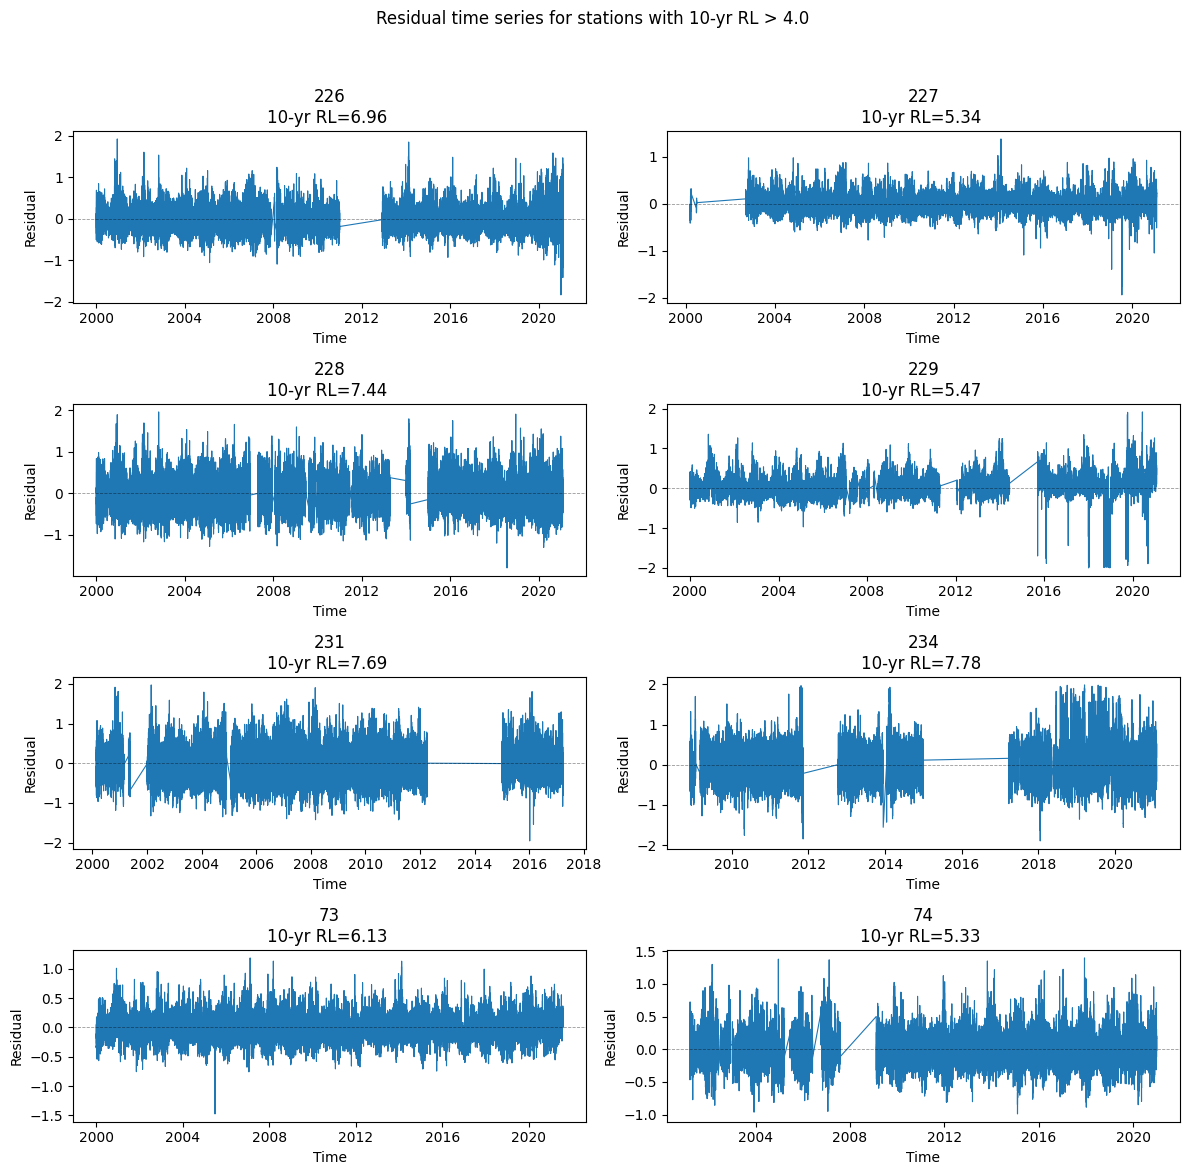

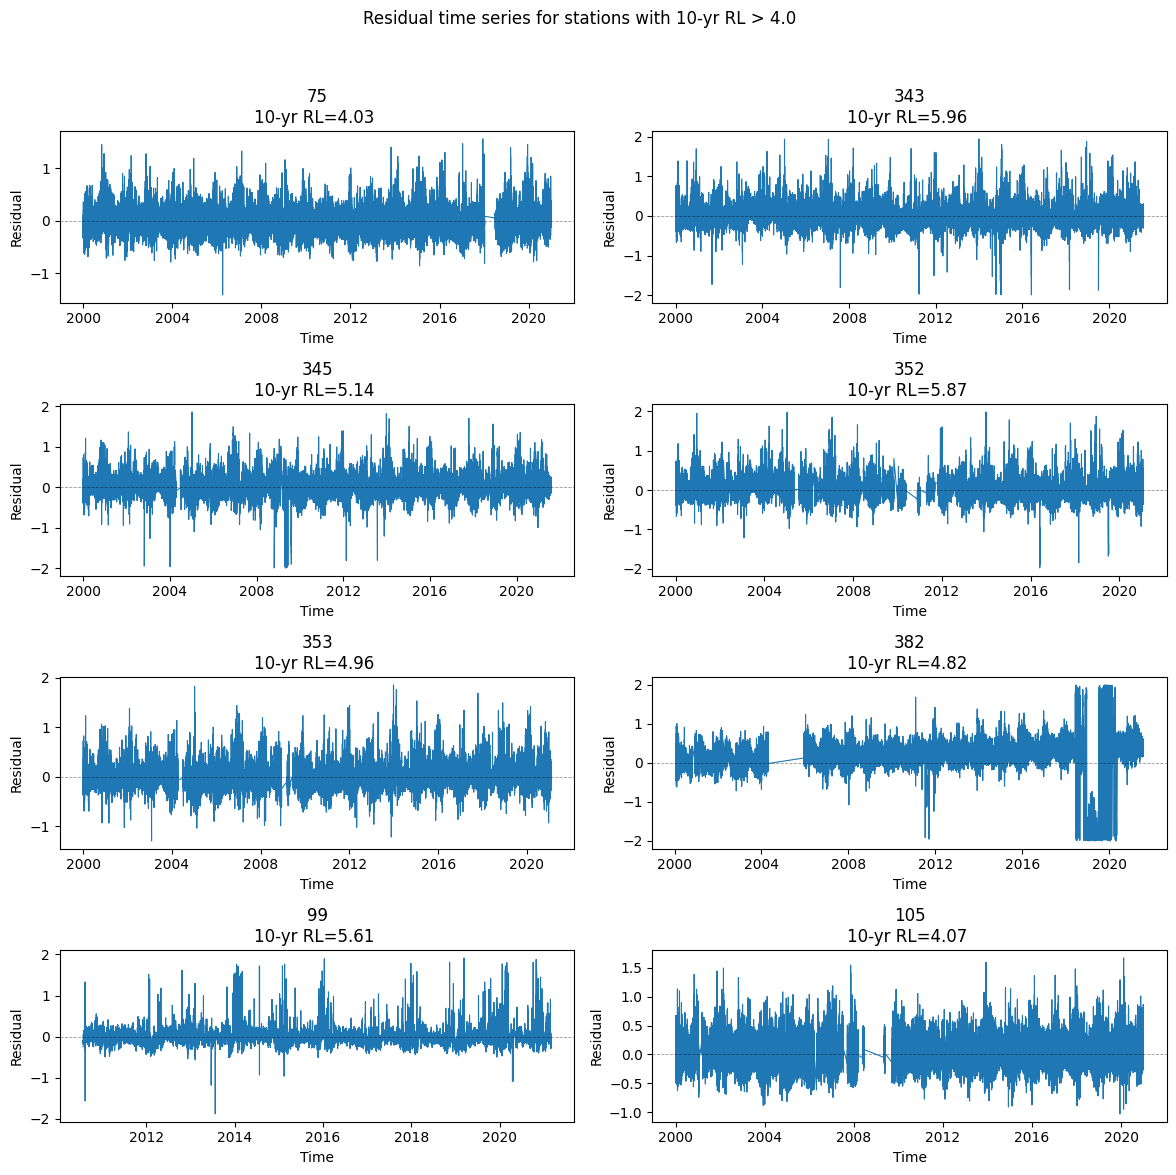

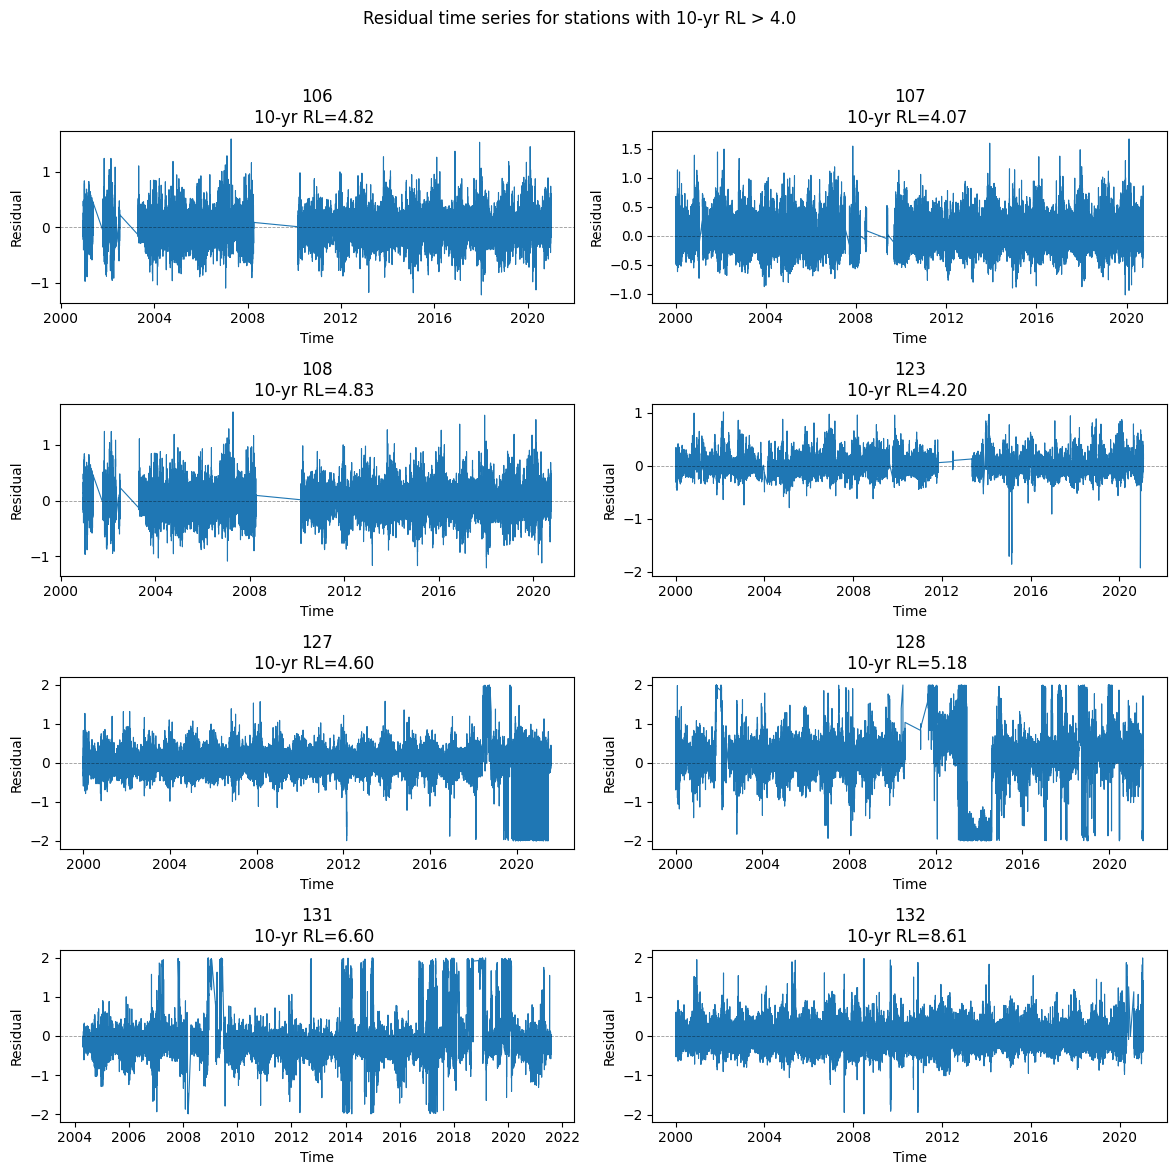

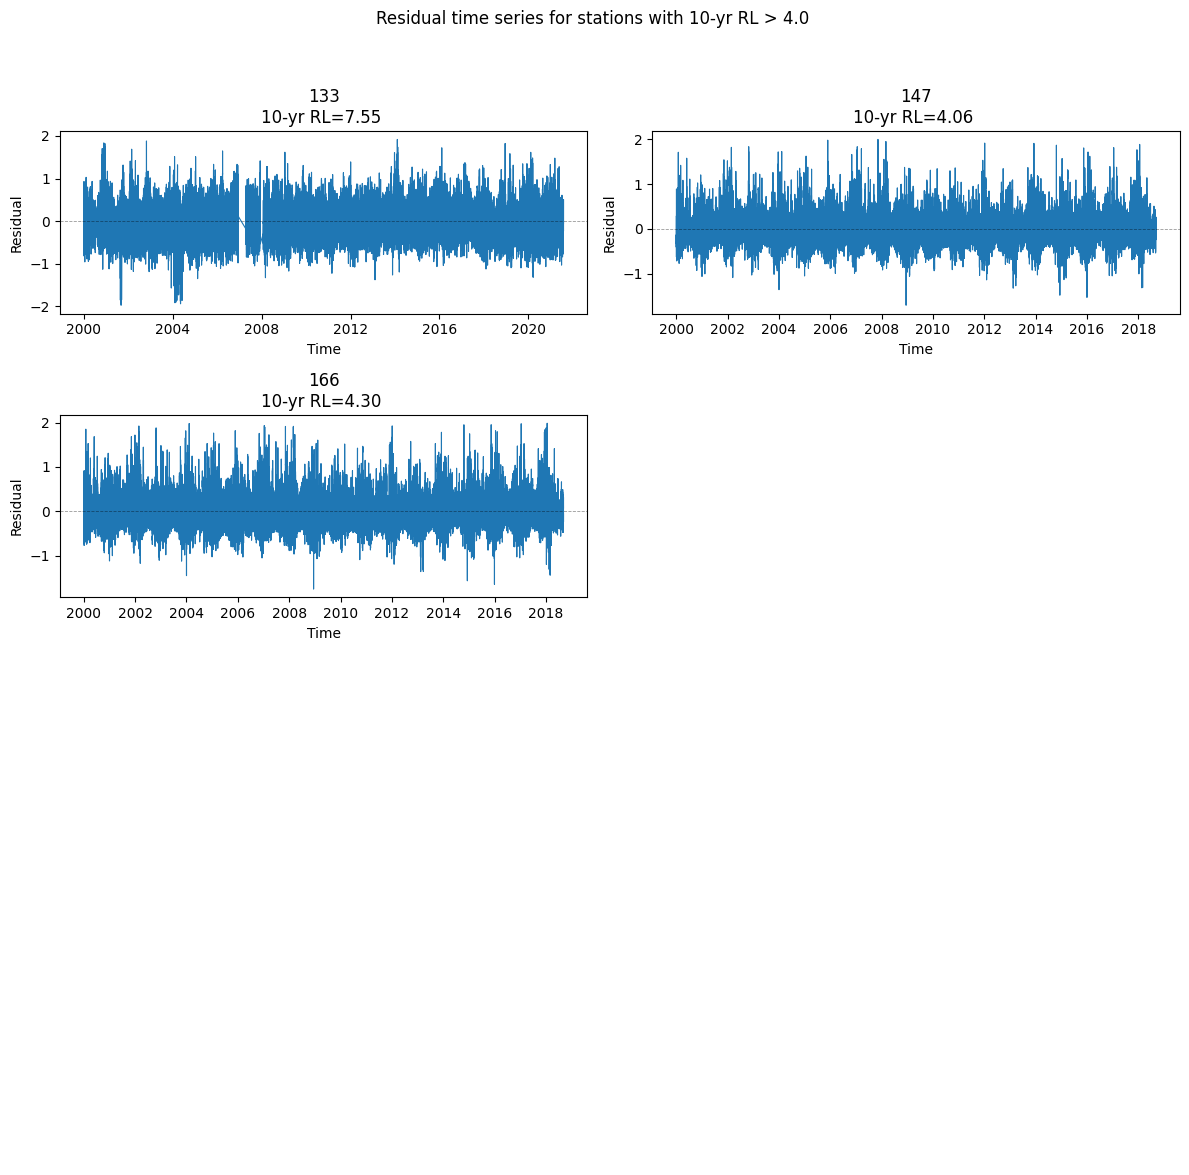

In [9]:
import math
import xarray as xr

# --- pick stations with 10-yr RL > 5 m (and at least 10 years) ---
thr = 4.0
mask = (tenyr_rl > thr) & (n_years >= 10)
hot = tenyr_rl.where(mask, drop=True)          # (station,)
hot_idx = hot.get_index("station")             # indexer to select stations
print(f"{hot.sizes.get('station', 0)} stations exceed {thr} m 10-yr RL")

# Try to get readable station labels
if "station_name" in ds:
    station_labels = ds["station_name"].sel(station=hot_idx).astype(str).values
elif "station_id" in ds:
    station_labels = ds["station_id"].sel(station=hot_idx).astype(str).values
else:
    # fall back to coord value
    station_labels = [str(s) for s in hot["station"].values]

# --- plot residual time series for each selected station ---
# choose layout
n = hot.sizes["station"]
ncols = 2
nrows = min(4, math.ceil(n / ncols))  # up to 8 panels per figure
per_fig = ncols * nrows

# OPTIONAL: save all panels to a single PDF
from matplotlib.backends.backend_pdf import PdfPages
save_pdf = True
pdf_path = "residual_timeseries_hotstations.pdf"
pdf = PdfPages(pdf_path) if save_pdf else None

for i0 in range(0, n, per_fig):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3.0*nrows), sharex=False, sharey=False)
    axes = np.atleast_1d(axes).ravel()

    for ax, j in zip(axes, range(i0, min(i0+per_fig, n))):
        st_sel = hot.isel(station=j)
        st_id = st_sel["station"].item()
        ts = ds["residual"].sel(station=st_id).dropna("valid_time")
        # sort by time just in case
        ts = ts.sortby("valid_time")

        ax.plot(ts["valid_time"].values, ts.values, lw=0.8)
        ax.axhline(0, lw=0.6, ls="--", color="k", alpha=0.4)
        ax.set_title(f"{station_labels[j]}\n10-yr RL={float(st_sel.values):.2f} {units or ''}")
        ax.set_xlabel("Time")
        ax.set_ylabel(f"Residual ({units})" if units else "Residual")

    # Hide unused axes on the last page
    for ax in axes[(min(i0+per_fig, n) - i0):]:
        ax.axis("off")

    fig.suptitle(f"Residual time series for stations with 10-yr RL > {thr} {units or ''}", y=0.995)
    fig.tight_layout(rect=[0, 0.02, 1, 0.97])